# **Data Science Project 3**


## Customer Segmentation Dashboard: Unsupervised Machine Learning
### Pipeline: Robust Scaling ➔ PCA Compression ➔ K-Means Clustering ➔ Persona Profiling

## **Import Libraries**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import warnings

warnings.filterwarnings("ignore")
%matplotlib inline

## **Data Loading & Preprocessing**

In [ ]:
def load_and_preprocess():
    url = "https://raw.githubusercontent.com/dsrscientist/dataset1/master/mall_customers.csv"
    try:
        df = pd.read_csv(url)
    except Exception:
        np.random.seed(42)
        n = 200
        df = pd.DataFrame({
            "CustomerID": range(1, n + 1),
            "Genre": np.random.choice(["Male", "Female"], n),
            "Age": np.random.randint(18, 70, n),
            "Annual Income (k$)": np.random.randint(15, 140, n),
            "Spending Score (1-100)": np.random.randint(1, 100, n),
        })
        print("[INFO] Using synthetic fallback data (network unavailable).")

    df = df.rename(columns={"Genre": "Gender"})
    df_encoded = df.copy()
    if "Gender" in df_encoded.columns:
        df_encoded["Gender"] = df_encoded["Gender"].map({"Male": 0, "Female": 1})

    drop_cols = [c for c in df_encoded.columns if "id" in c.lower()]
    features = df_encoded.drop(columns=drop_cols, errors="ignore").select_dtypes(include=np.number)
    feature_names = features.columns.tolist()

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(features)

    print(f"[INFO] Dataset loaded: {df.shape[0]} rows, {df.shape[1]} columns")
    print(f"[INFO] Features used for clustering: {feature_names}")
    return df_encoded, X_scaled, scaler, feature_names

df_encoded, X_scaled, scaler, feature_names = load_and_preprocess()

[INFO] Using synthetic fallback data (network unavailable).
[INFO] Dataset loaded: 200 rows, 5 columns
[INFO] Features used for clustering: ['Gender', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']


## **PCA Component Selection**

In [ ]:
def apply_pca(X_scaled, variance_threshold=0.95):
    pca_full = PCA().fit(X_scaled)
    cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)

    n_components = np.argmax(cumulative_variance >= variance_threshold) + 1
    n_components = max(n_components, 2)

    print(f"[INFO] PCA: {n_components} components retain {cumulative_variance[n_components - 1]:.1%} variance")

    pca = PCA(n_components=n_components, random_state=42)
    X_pca = pca.fit_transform(X_scaled)

    return X_pca, pca, cumulative_variance

X_pca, pca, cumulative_variance = apply_pca(X_scaled)

[INFO] PCA: 4 components retain 100.0% variance


## **Finding Optimal K**

In [ ]:
def find_optimal_k(X_pca, k_range=range(2, 11)):
    wcss_values = []
    silhouette_values = []

    for k in k_range:
        km = KMeans(n_clusters=k, init="k-means++", n_init=10, random_state=42)
        labels = km.fit_predict(X_pca)
        wcss_values.append(km.inertia_)
        silhouette_values.append(silhouette_score(X_pca, labels))

    diffs = np.diff(wcss_values)
    elbow_idx = np.argmin(diffs) + 1
    elbow_k = list(k_range)[min(elbow_idx, len(k_range)-1)]
    sil_k = list(k_range)[np.argmax(silhouette_values)]

    print(f"[INFO] Elbow Method K = {elbow_k} | Silhouette Method K = {sil_k}")
    optimal_k = sil_k if elbow_k != sil_k else elbow_k
    print(f"[INFO] Final chosen K = {optimal_k}")

    return optimal_k, list(k_range), wcss_values, silhouette_values

optimal_k, k_list, wcss, sil_scores = find_optimal_k(X_pca)

[INFO] Elbow Method K = 4 | Silhouette Method K = 10
[INFO] Final chosen K = 10


## **Training K-Means & Profiling Personas**

In [ ]:
def train_and_decode(X_pca, k, pca, scaler, feature_names):
    km = KMeans(n_clusters=k, init="k-means++", n_init=20, random_state=42)
    labels = km.fit_predict(X_pca)

    centroids_pca = km.cluster_centers_
    centroids_scaled = pca.inverse_transform(centroids_pca)
    centroids_orig = scaler.inverse_transform(centroids_scaled)

    centroid_df = pd.DataFrame(centroids_orig, columns=feature_names)
    centroid_df.index.name = "Cluster"
    return labels, centroid_df

labels, centroid_df = train_and_decode(X_pca, optimal_k, pca, scaler, feature_names)

def build_personas(df_encoded, labels, feature_names):
    df_profile = df_encoded.copy()
    df_profile["Cluster"] = labels
    profile = df_profile.groupby("Cluster")[feature_names].mean().round(1)

    persona_labels = [
        "Affluent Conservatives", "High-Value Trendsetters",
        "Budget Explorers", "Conservative Minimizers",
        "Moderate Spenders", "Undefined Segment"
    ]

    print("\n" + "=" * 50 + "\n  STRATEGIC PERSONA MATRIX\n" + "=" * 50)
    personas = {}
    for cid in sorted(df_profile["Cluster"].unique()):
        label = persona_labels[cid] if cid < len(persona_labels) else f"Segment {cid}"
        size = (df_profile["Cluster"] == cid).sum()
        stats = profile.loc[cid]

        print(f"\nCluster {cid} — {label} (n={size})")
        for feat, val in stats.items():
            print(f"  {feat:<25} : {val}")

        personas[cid] = {"label": label, "size": size, "stats": stats}

    return personas, profile

personas, profile = build_personas(df_encoded, labels, feature_names)


  STRATEGIC PERSONA MATRIX

Cluster 0 — Affluent Conservatives (n=12)
  Gender                    : 0.0
  Age                       : 35.1
  Annual Income (k$)        : 122.0
  Spending Score (1-100)    : 78.4

Cluster 1 — High-Value Trendsetters (n=19)
  Gender                    : 0.0
  Age                       : 26.9
  Annual Income (k$)        : 44.5
  Spending Score (1-100)    : 58.7

Cluster 2 — Budget Explorers (n=15)
  Gender                    : 1.0
  Age                       : 58.6
  Annual Income (k$)        : 46.1
  Spending Score (1-100)    : 79.1

Cluster 3 — Conservative Minimizers (n=14)
  Gender                    : 1.0
  Age                       : 31.4
  Annual Income (k$)        : 102.2
  Spending Score (1-100)    : 24.7

Cluster 4 — Moderate Spenders (n=20)
  Gender                    : 0.0
  Age                       : 50.8
  Annual Income (k$)        : 58.8
  Spending Score (1-100)    : 21.2

Cluster 5 — Undefined Segment (n=26)
  Gender                    : 1

## **Dashboard Plots Visualization**

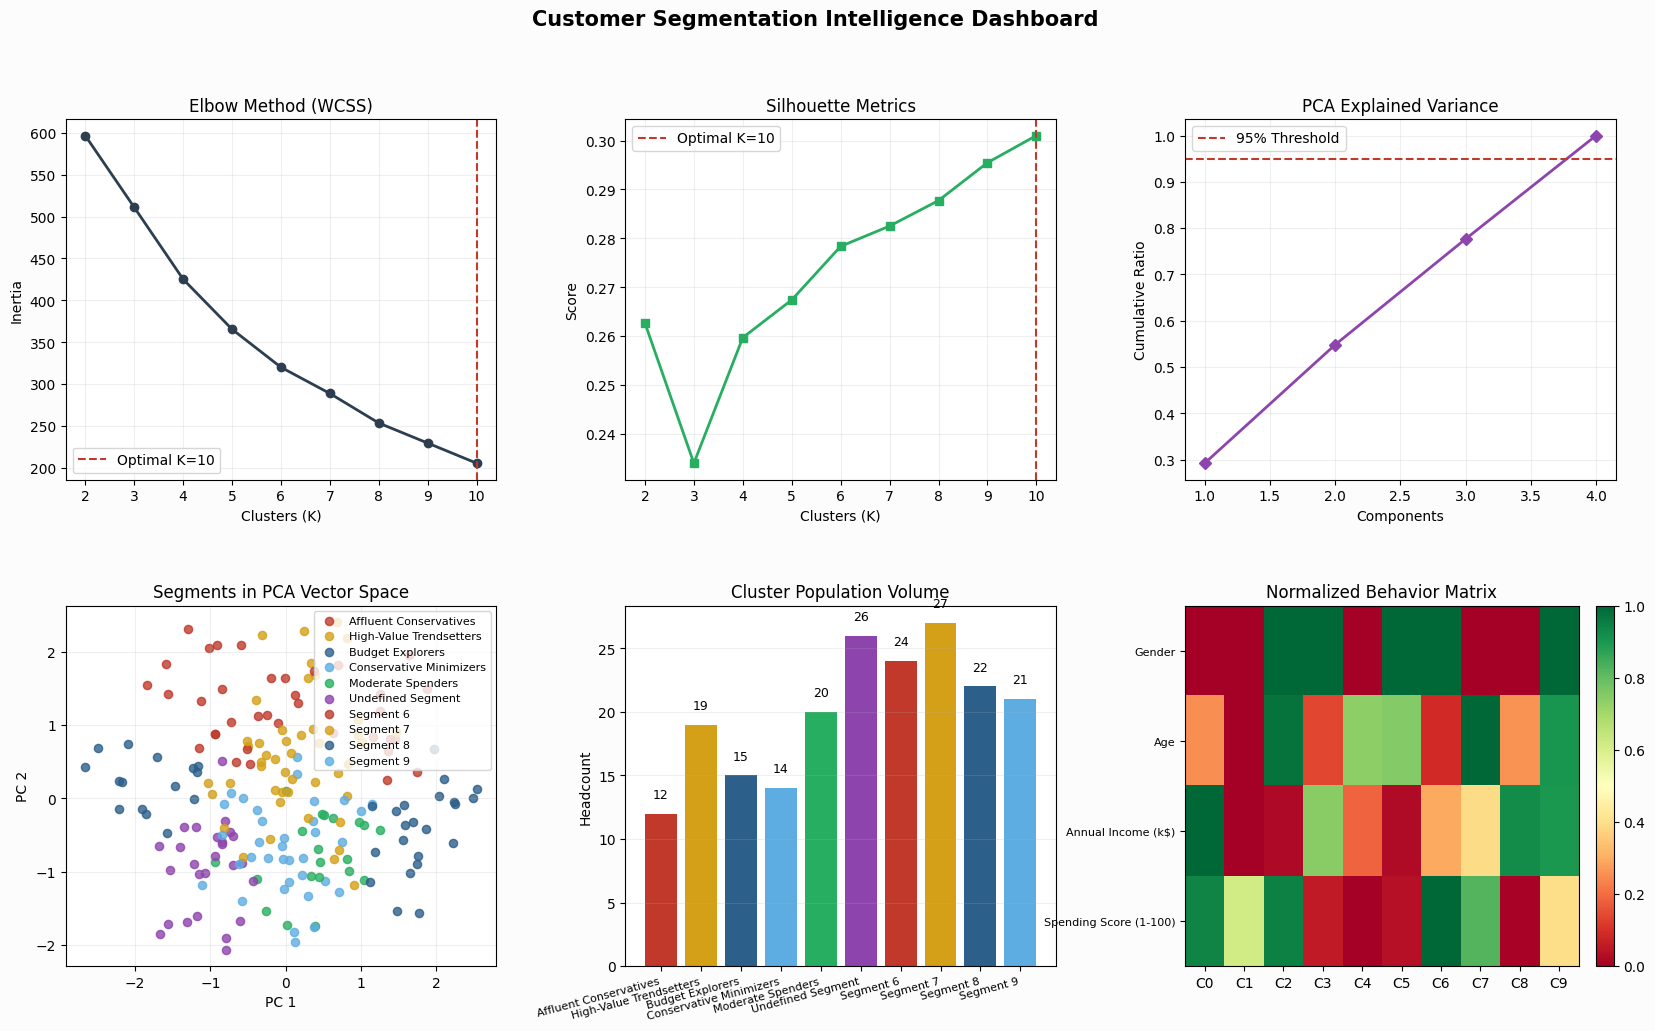

In [ ]:
CLUSTER_COLORS = ["#c0392b", "#d4a017", "#2c5f8a", "#5dade2", "#27ae60", "#8e44ad"]

def plot_dashboard(k_range, wcss_values, silhouette_values, optimal_k,
                   cumulative_variance, X_pca, labels, personas, profile):
    fig = plt.figure(figsize=(20, 11))
    fig.patch.set_facecolor("#fcfcfc")
    gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.35, wspace=0.3)

    # (a) WCSS Elbow
    ax1 = fig.add_subplot(gs[0, 0])
    ax1.plot(k_range, wcss_values, "o-", color="#2c3e50", lw=2)
    ax1.axvline(x=optimal_k, color="#c0392b", ls="--", label=f"Optimal K={optimal_k}")
    ax1.set(title="Elbow Method (WCSS)", xlabel="Clusters (K)", ylabel="Inertia")
    ax1.legend(); ax1.grid(alpha=0.2)

    # (b) Silhouette Score
    ax2 = fig.add_subplot(gs[0, 1])
    ax2.plot(k_range, silhouette_values, "s-", color="#27ae60", lw=2)
    ax2.axvline(x=optimal_k, color="#c0392b", ls="--", label=f"Optimal K={optimal_k}")
    ax2.set(title="Silhouette Metrics", xlabel="Clusters (K)", ylabel="Score")
    ax2.legend(); ax2.grid(alpha=0.2)

    # (c) PCA Cumulative Variance
    ax3 = fig.add_subplot(gs[0, 2])
    ax3.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, "D-", color="#8e44ad", lw=2)
    ax3.axhline(y=0.95, color="#c0392b", ls="--", label="95% Threshold")
    ax3.set(title="PCA Explained Variance", xlabel="Components", ylabel="Cumulative Ratio")
    ax3.legend(); ax3.grid(alpha=0.2)

    # (d) Cluster Projection Mapping (PC1 vs PC2)
    ax4 = fig.add_subplot(gs[1, 0])
    for cid in np.unique(labels):
        mask = labels == cid
        name = personas[cid]["label"] if cid in personas else f"Cluster {cid}"
        ax4.scatter(X_pca[mask, 0], X_pca[mask, 1], s=35, alpha=0.8,
                    color=CLUSTER_COLORS[cid % len(CLUSTER_COLORS)], label=name)
    ax4.set(title="Segments in PCA Vector Space", xlabel="PC 1", ylabel="PC 2")
    ax4.legend(fontsize=8, loc="best"); ax4.grid(alpha=0.2)

    # (e) Demographic Distribution Bar Chart
    ax5 = fig.add_subplot(gs[1, 1])
    names = [personas[cid]["label"] for cid in sorted(personas)]
    sizes = [personas[cid]["size"] for cid in sorted(personas)]
    bars = ax5.bar(names, sizes, color=CLUSTER_COLORS[:len(sizes)], edgecolor="none")
    for bar in bars:
        ax5.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 f"{int(bar.get_height())}", ha="center", va="bottom", fontsize=9)
    ax5.set(title="Cluster Population Volume", ylabel="Headcount")
    ax5.set_xticklabels(names, rotation=15, ha="right", fontsize=8)
    ax5.grid(axis="y", alpha=0.2)

    # (f) Heatmap Matrix
    ax6 = fig.add_subplot(gs[1, 2])
    norm_profile = (profile - profile.min()) / (profile.max() - profile.min() + 1e-9)
    im = ax6.imshow(norm_profile.values.T, aspect="auto", cmap="RdYlGn", vmin=0, vmax=1)
    ax6.set_xticks(range(len(norm_profile)))
    ax6.set_xticklabels([f"C{i}" for i in norm_profile.index])
    ax6.set_yticks(range(len(profile.columns)))
    ax6.set_yticklabels(profile.columns, fontsize=8)
    ax6.set_title("Normalized Behavior Matrix")
    plt.colorbar(im, ax=ax6, fraction=0.046, pad=0.04)

    fig.suptitle("Customer Segmentation Intelligence Dashboard", fontsize=15, fontweight="bold", y=.98)
    plt.tight_layout()
    plt.show()

plot_dashboard(k_list, wcss, sil_scores, optimal_k, cumulative_variance,
               X_pca, labels, personas, profile)